In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser = 'auto')
X, y = mnist['data'], mnist['target']
print('Датасет загружен!')

Датасет загружен!


In [3]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

y_train = y_train.astype(int)
y_test = y_test.astype(int)

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [4]:
print('Обучение...')
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)
print('Модель обучена!')

Обучение...
Модель обучена!


In [5]:
y_pred_5 = sgd_clf.predict(X_test)
print('Оценка')
print(classification_report(y_test_5, y_pred_5))

Оценка
              precision    recall  f1-score   support

       False       0.99      0.96      0.97      9108
        True       0.66      0.88      0.76       892

    accuracy                           0.95     10000
   macro avg       0.82      0.92      0.86     10000
weighted avg       0.96      0.95      0.95     10000



In [6]:
# делаем мультиклассвое обучение
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [7]:
sgd_clf.fit(X_train, y_train)
print('Модель обучена!')


Модель обучена!


In [8]:
y_pred = sgd_clf.predict(X_test)

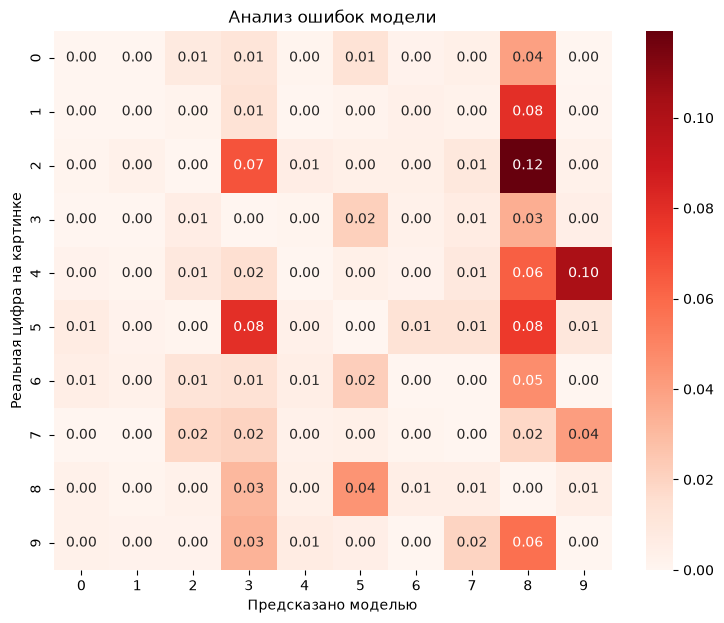

In [10]:
conf_mx = confusion_matrix(y_test, y_pred)

row_sums = conf_mx.sum(axis=1,keepdims=True)
norm_conf_mx = conf_mx / row_sums
np.fill_diagonal(norm_conf_mx, 0)

plt.figure(figsize=(9, 7))
sns.heatmap(norm_conf_mx, annot=True, fmt=".2f", cmap="Reds")
plt.title("Анализ ошибок модели")
plt.xlabel("Предсказано моделью")
plt.ylabel("Реальная цифра на картинке")
plt.show()

In [11]:
# многовидовая классификация 
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 != 0)

y_multilabel = np.c_[y_train_large, y_train_odd]

In [12]:
print('Обучаем многовидовую модель...')
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
print('Модель обучена')


Обучаем многовидовую модель...
Модель обучена


In [15]:
some_digit = X_test[0]
print(f'Реальная цифра на тесте: {y_test[0]}')

pred = knn_clf.predict([some_digit])
print(f'Предсказание модели: {pred}')

Реальная цифра на тесте: 7
Предсказание модели: [[ True  True]]


In [16]:
# многовыходная классификация
noise_train = np.random.randint(0, 200, (len(X_train), 784))
noise_test = np.random.randint(0, 200, (len(X_test), 784))

X_train_mod = X_train + noise_train
X_test_mod = X_test + noise_test

y_train_mod = X_train
y_test_mod = X_test

print("Обучаем модель...")
knn_clf.fit(X_train_mod, y_train_mod)
print("Модель обучена!")

Обучаем модель...
Модель обучена!


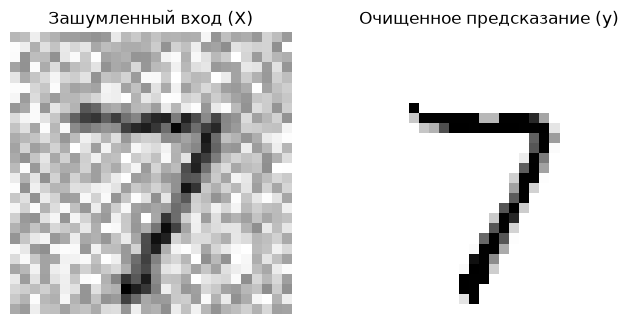

In [17]:
some_index = 0
dirty_digit = X_test_mod[some_index]

clean_digit_pred = knn_clf.predict([dirty_digit])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(dirty_digit.reshape(28, 28), cmap="binary")
plt.title("Зашумленный вход (X)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_digit_pred.reshape(28, 28), cmap="binary")
plt.title("Очищенное предсказание (y)")
plt.axis("off")

plt.show()